In Problem 04 of Assignment_01, ﬁnd out the number of pixels per square inch (DPI)
for both the images taken at 50 cm and 80 cm respectively.

In [1]:
import cv2
import matplotlib.pyplot as plt

d50=cv2.imread('50.jpeg',cv2.IMREAD_GRAYSCALE)
d80=cv2.imread('80.jpeg',cv2.IMREAD_GRAYSCALE)


In [3]:
cv2.imshow('title',d50)
cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/aswin/ml_proj/.venv/lib/python3.11/site-packages/cv2/qt/plugins"


In [14]:
dim_50=d50.shape
dim_80=d80.shape
print(dim_50, dim_80)
# We have 960/1280 images both

(960, 1280) (960, 1280)


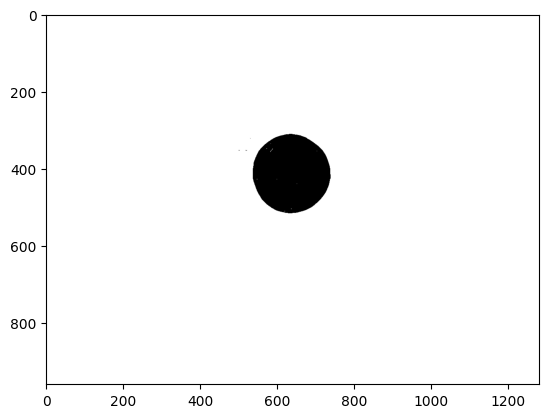

In [22]:
# d50_bw = d50.copy()
#print(h,w)
def bw_convert(img,T=90):
    bw = img.copy()
    h, w = img.shape
    for i in range(h):
        for j in range(w):
            if img[i,j]>=T:
                bw[i,j] = 255
            else:
                bw[i,j] = 0
    return bw

d50_bw=bw_convert(d50)
# cleaniing up
h, w = d50.shape

for i in range (520,h):
    for j in range(w):
        d50_bw[i,j] = 255
for i in range (h):
    for j in range (740,w):
        d50_bw[i,j] = 255
for i in range(h):
    for j in range(0,500):
        d50_bw[i,j] = 255
plt.imshow(d50_bw, cmap='gray')
plt.show()

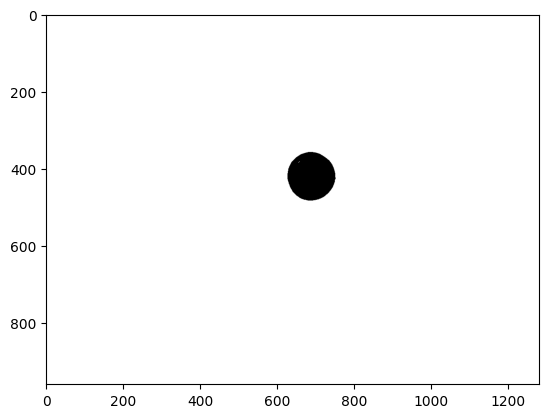

In [23]:
d80_bw = bw_convert(d80)
# adjust

for i in range (490,h):
    for j in range(w):
        d80_bw[i,j] = 255
for i in range (h):
    for j in range (754,w):
        d80_bw[i,j] = 255
for i in range(h):
    for j in range(0,600):
        d80_bw[i,j] = 255
plt.imshow(d80_bw, cmap='gray')
plt.show()

In [20]:
# measuring the area in pixels
def area_count(img):
    circle_area = 0
    for i in range(h):
        for j in range(w):
            if img[i,j] == 0:
                circle_area+=1
    return(circle_area) 
    
ax=area_count(d50_bw)
ay=area_count(d80_bw)

print(f'area of 50cm away circle is {ax} and that of 80cm away circle is {ay}')


area of 50cm away circle is 32297 and that of 80cm away circle is 12206


## Answer
After doing the conversion of area -> radius.
- radius in px/ actual radius in inch
- obtained linear pixel density
- squared to get DPI (pixels per sq inch)


# Q2
Put image in aJached document Number_of_Lines_Assignment_02.pdf in matrix
form of greyscale intensity. Describe your own algorithm to count number of lines. Implement your algorithm to count number of lines in the document:
Number_of_Lines_Assignment_02.pdf

In [24]:
img = cv2.imread('lines.jpg',cv2.IMREAD_GRAYSCALE)
img=bw_convert(img)

h,w=img.shape
lin_count=0
white_check=False

for i in range(h):
    black_num=0
    for j in range(w):
        if int(img[i,j])==0:
        #this is where it detects first black pixel
            black_num +=1
    if black_num >100:
        if not white_check:
            lin_count+=1
            white_check = True
    else:
        white_check=False
        

print(lin_count)

45


# Q3
Use diﬀerent thresholding algorithms on the following image to generate and save
the binary image after thresholding.

In [22]:
import cv2
import matplotlib.pyplot as plt

In [25]:
polka=cv2.imread('polka.png')
bw_polka = cv2.imread('polka.png', cv2.IMREAD_GRAYSCALE)
polka.shape

# Colored thresholding - bg white, color shown
def color_convert(img, T=80):
    color = img.copy()
    h, w, c= img.shape
    for i in range(h):
        for j in range(w):
            for k in range(c):
                if img[i,j,k]>=T:
                    color[i,j,k] = 255
                else:
                    color[i,j] = 0
    return color
# black and white thresholding (binary)
lkjhgvcxbw_polka = bw_convert(bw_polka)
color_polka =color_convert(polka)

In [6]:
cv2.imshow('title',bw_polka)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
cv2.imshow('title',polka)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
cv2.imshow('title',color_polka)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Q4
Draw a fence of an arbitrary shape by hand (!) on a clean paper with white
background and printed lines on it as explained in the class. Take a photo of this
image. Write a program:

a) to read the photographed image and translate it to a gray scale image of size say, 300 x 300 of this image.

b)Use global thresholding algorithm to clean image to remove all unwanted lines on it if any.

c) Save original and binary image by name fence_original.jpg and fence_threshold.jpg.

d) Write a program to draw a ﬁlled circle of radius 5 randomly in this image
(fence_threshold.jpg). 

Generate 50 such images. Store these images into two folders as explained in the class.

In [110]:
def mean_filter(n):
    mat = []
    for i in range(n):
        row = []
        for j in range(n):
            row.append(1)
        mat.append(row)
    #dividing
    div=n**2
    for i in range(n):
        for j in range(n):
            val= round(mat[i][j]/div, 5)
            mat[i][j]=val
    return mat

# my mean filter will have a 20 padding and 4 step size with 300 steps = 1200+ 4*20= 1280

filter_=mean_filter(81)
# print(mean_filter)
## Apply mean filter to image
k=len(filter_)
print(k)


81


In [121]:
img=cv2.imread('fence.jpg', cv2.IMREAD_GRAYSCALE)
bw_img=bw_convert(fence, 65)
img.shape

(1280, 1280)

In [ ]:
img_len = 1280
filter_size = len(filter_)
print(filter_size)
stride = 4 
out_len = (img_len - filter_size) // stride + 1 ]
print(out_len)

# output 
output = []
for i in range(out_len):
    row = []
    for j in range(out_len):
        # starting position, input image
        start_i = i * stride
        start_j = j * stride
        sum_val = 0
        for fi in range(filter_size):
            for fj in range(filter_size):
                img_val = img[start_i + fi][start_j + fj]
                filter_val = filter_[fi][fj]
                sum_val += img_val * filter_val
        row.append(sum_val)
    output.append(row)

# print(len(output)) 
# print(len(output[0])) 

In [77]:
cv2.imshow('title',output)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [78]:
cv2.imshow('title',x)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'imshow'
> Overload resolution failed:
>  - mat is not a numpy array, neither a scalar
>  - Expected Ptr<cv::cuda::GpuMat> for argument 'mat'
>  - Expected Ptr<cv::UMat> for argument 'mat'
